<a href="https://colab.research.google.com/github/Shalaka127/Walmart_Sales_Analysis_Forecasting/blob/main/Walmart_Sales_Analysis_Forecasting_shalaka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Walmart Retail Store — Sales Analysis & Forecasting

---

## Problem Statement

A retail store with **multiple outlets** across the country is facing inventory management challenges — balancing **demand vs. supply**.

As a Data Scientist, the objectives are:
1. **Extract useful insights** from historical sales data to help each store improve operations.
2. **Forecast weekly sales** for each store for the **next 12 weeks**.

---

### Dataset: `Walmart_DataSet.csv`
| Feature | Description |
|---|---|
| Store | Store number |
| Date | Week of Sales |
| Weekly_Sales | Sales for the given store in that week |
| Holiday_Flag | Whether it is a holiday week (1 = Yes, 0 = No) |
| Temperature | Temperature on the day of the sale |
| Fuel_Price | Cost of fuel in the region |
| CPI | Consumer Price Index |
| Unemployment | Unemployment Rate |

**Dataset size:** 6435 rows × 8 columns | **45 Stores** | **143 weeks** of data

---
##  Section 1: Install & Import Libraries

In [1]:
# Install required libraries (run once in Colab)
!pip install prophet scikit-learn xgboost statsmodels matplotlib seaborn --quiet

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

# Plot settings
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print(" All libraries loaded successfully!")

 All libraries loaded successfully!


---
##  Section 2: Load Dataset

In [3]:
# Upload Walmart_DataSet.csv when prompted, OR mount Google Drive
from google.colab import files
uploaded = files.upload()   # Upload Walmart_DataSet.csv

Saving Walmart DataSet.csv to Walmart DataSet.csv


In [8]:
df = pd.read_csv('Walmart DataSet.csv')

# Parse dates — Walmart dataset uses DD-MM-YYYY format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.sort_values(['Store', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape: {df.shape}")
print(f"Stores: {df['Store'].nunique()} unique stores")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head(10)

Shape: (6435, 8)
Stores: 45 unique stores
Date range: 2010-02-05 → 2012-10-26


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,2010-04-09,1545418.53,0,65.86,2.770,210.622857,7.808


---
##  Section 3: Exploratory Data Analysis (EDA)

In [9]:
# --- 3.1 Basic Info ---
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB

Null Values:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicates: 0


In [10]:
# --- 3.2 Descriptive Statistics ---
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,min,25%,50%,75%,max,std
Store,6435.000000,23.000000,1.000000,12.000000,23.000000,34.000000,45.000000,12.988182
Date,6435,2011-06-17 00:00:00,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,nan
Weekly_Sales,6435.000000,1046964.877562,209986.250000,553350.105000,960746.040000,1420158.660000,3818686.450000,564366.622054
Holiday_Flag,6435.000000,0.069930,0.000000,0.000000,0.000000,0.000000,1.000000,0.255049
Temperature,6435.000000,60.663782,-2.060000,47.460000,62.670000,74.940000,100.140000,18.444933
Fuel_Price,6435.000000,3.358607,2.472000,2.933000,3.445000,3.735000,4.468000,0.459020
CPI,6435.000000,171.578394,126.064000,131.735000,182.616521,212.743293,227.232807,39.356712
Unemployment,6435.000000,7.999151,3.879000,6.891000,7.874000,8.622000,14.313000,1.875885


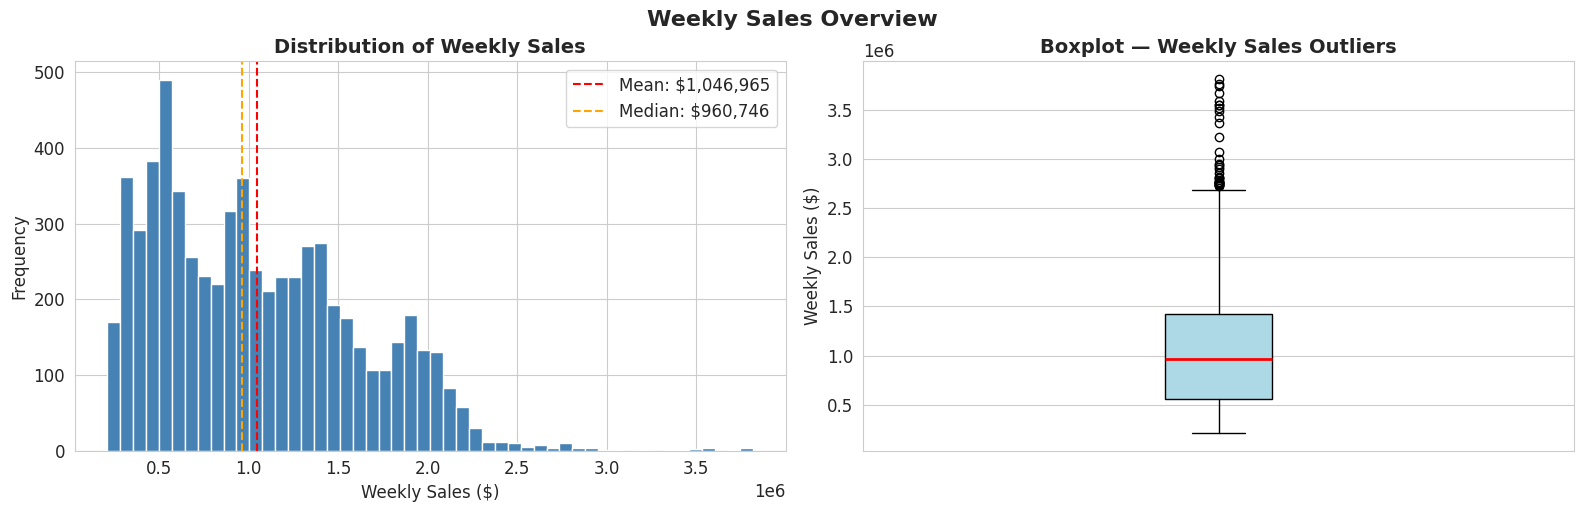

Skewness: 0.67 (Right-skewed — a few large stores dominate)


In [11]:
# --- 3.3 Distribution of Weekly Sales ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['Weekly_Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Weekly Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Weekly_Sales'].mean(), color='red', linestyle='--', label=f"Mean: ${df['Weekly_Sales'].mean():,.0f}")
axes[0].axvline(df['Weekly_Sales'].median(), color='orange', linestyle='--', label=f"Median: ${df['Weekly_Sales'].median():,.0f}")
axes[0].legend()

axes[1].boxplot(df['Weekly_Sales'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — Weekly Sales Outliers', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Weekly Sales ($)')
axes[1].set_xticks([])

plt.tight_layout()
plt.suptitle('Weekly Sales Overview', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('weekly_sales_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


## Observation

- The **Weekly Sales** distribution is **positively skewed (right-skewed)**, as the **mean sales ($1,046,965)** are higher than the **median sales ($960,746)**. This indicates the presence of a few exceptionally high sales values.

- Most weekly sales values are concentrated between **$400,000 and $1.5 million**, representing the typical sales range across stores.

- The boxplot reveals several **high-value outliers**, with some observations reaching nearly **$3.8 million**. These spikes may correspond to holiday periods, promotional campaigns, or top-performing stores.

- There are relatively few lower-end outliers, suggesting that significantly low sales weeks are uncommon.

- Overall, the dataset exhibits substantial variability in weekly sales, indicating that factors such as seasonality and special events should be considered while developing the forecasting model.

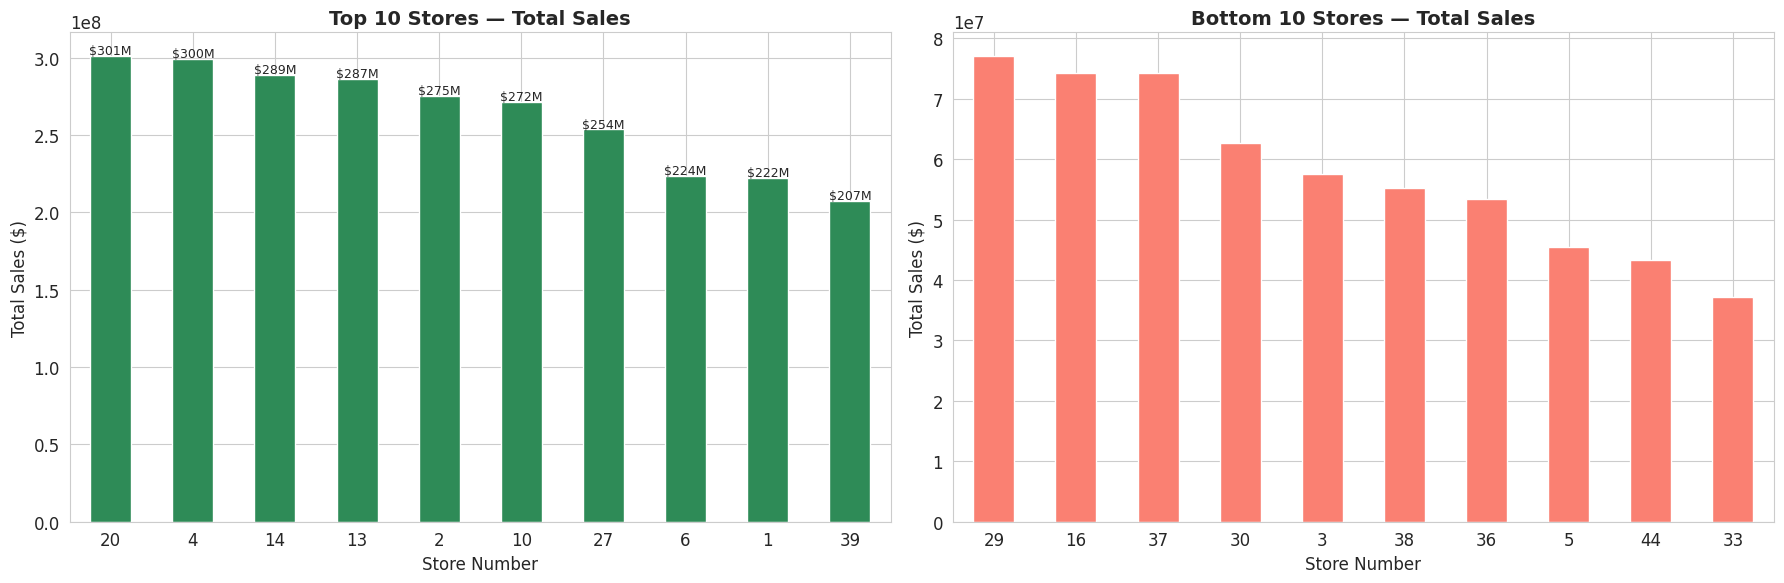


🏆 Top Store: Store 20 — $301.4M total sales
📉 Lowest Store: Store 33 — $37.2M total sales


In [12]:
# --- 3.4 Total Sales by Store (Top & Bottom 10) ---
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 10
store_sales.head(10).plot(kind='bar', ax=axes[0], color='seagreen', edgecolor='white')
axes[0].set_title('Top 10 Stores — Total Sales', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Store Number')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e6,
                 f"${bar.get_height()/1e6:.0f}M", ha='center', fontsize=9)

# Bottom 10
store_sales.tail(10).plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Bottom 10 Stores — Total Sales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Store Number')
axes[1].set_ylabel('Total Sales ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('store_total_sales.png', bbox_inches='tight', dpi=150)
plt.show()



## Observation

- There is a significant variation in total sales across stores, indicating differences in customer demand and store performance.

- **Store 20** recorded the highest cumulative sales of approximately **$301 million**, followed closely by **Store 4 ($300 million)** and **Store 14 ($289 million)**.

- The top-performing stores consistently generated over **$250 million** in total sales, making them key contributors to the overall business revenue.

- In contrast, **Store 33** reported the lowest total sales at approximately **$37 million**, while Stores **44** and **5** also ranked among the lowest performers.

- The substantial gap between the top and bottom-performing stores suggests that factors such as location, customer traffic, demographics, and local market conditions may significantly influence sales performance.

- These insights can help management optimize inventory allocation, marketing strategies, and operational planning by focusing on store-specific demand patterns.

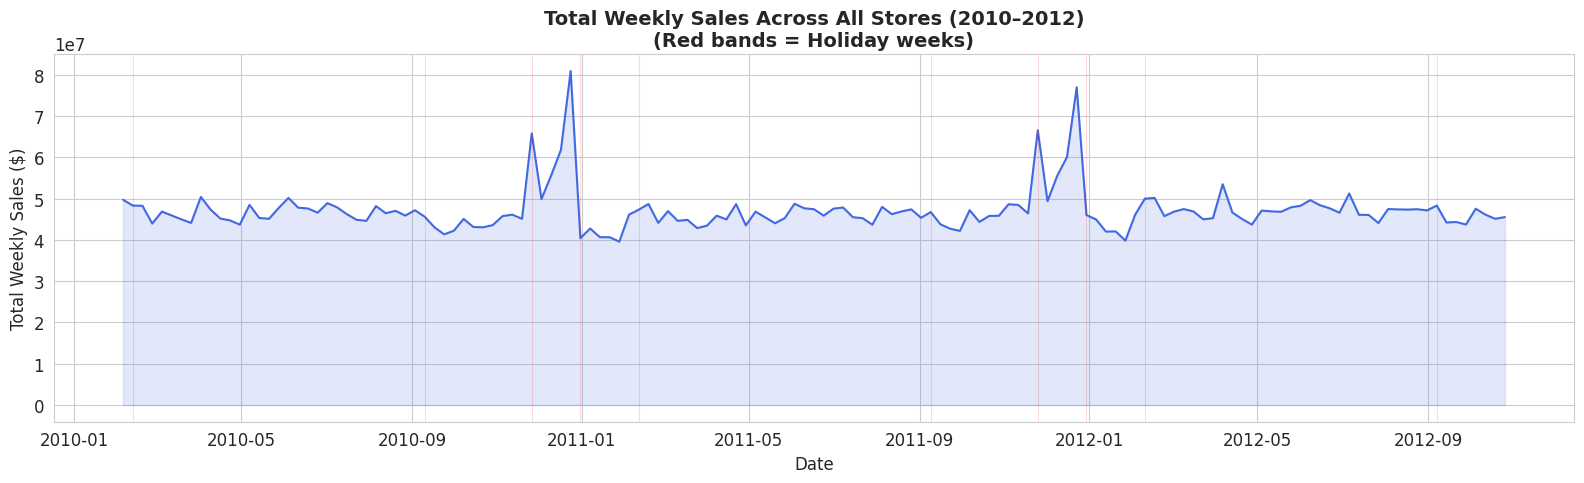

In [13]:
# --- 3.5 Overall Weekly Sales Trend Over Time ---
weekly_total = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(16, 5))
plt.plot(weekly_total['Date'], weekly_total['Weekly_Sales'], color='royalblue', linewidth=1.5)
plt.fill_between(weekly_total['Date'], weekly_total['Weekly_Sales'], alpha=0.15, color='royalblue')

# Mark holiday weeks
holiday_dates = df[df['Holiday_Flag'] == 1]['Date'].unique()
for d in holiday_dates:
    plt.axvline(x=d, color='red', alpha=0.15, linewidth=0.8)

plt.title('Total Weekly Sales Across All Stores (2010–2012)\n(Red bands = Holiday weeks)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales ($)')
plt.tight_layout()
plt.savefig('sales_trend_over_time.png', bbox_inches='tight', dpi=150)
plt.show()

## Observation

- The overall weekly sales remained relatively stable between **2010 and 2012**, generally fluctuating between **$40 million and $50 million**.

- Significant sales spikes are observed during the **holiday weeks** (highlighted by the red bands), indicating a strong positive impact of seasonal events on retail demand.

- The highest sales peaks occurred during the **year-end holiday seasons**, where total weekly sales exceeded **$75 million**, substantially higher than the average weekly sales.

- Following these peak periods, sales typically returned to their normal levels, suggesting that the increased demand was temporary and event-driven.

- Apart from holiday-related surges, there is no strong long-term upward or downward trend in the overall sales pattern, indicating relatively consistent business performance over the observed period.

- These findings highlight the importance of incorporating **holiday effects and seasonality** into forecasting models to improve prediction accuracy and inventory planning.

Holiday_Flag         mean     median          sum
 Non-Holiday 1.041256e+06  956211.20 6.231919e+09
     Holiday 1.122888e+06 1018538.04 5.052996e+08


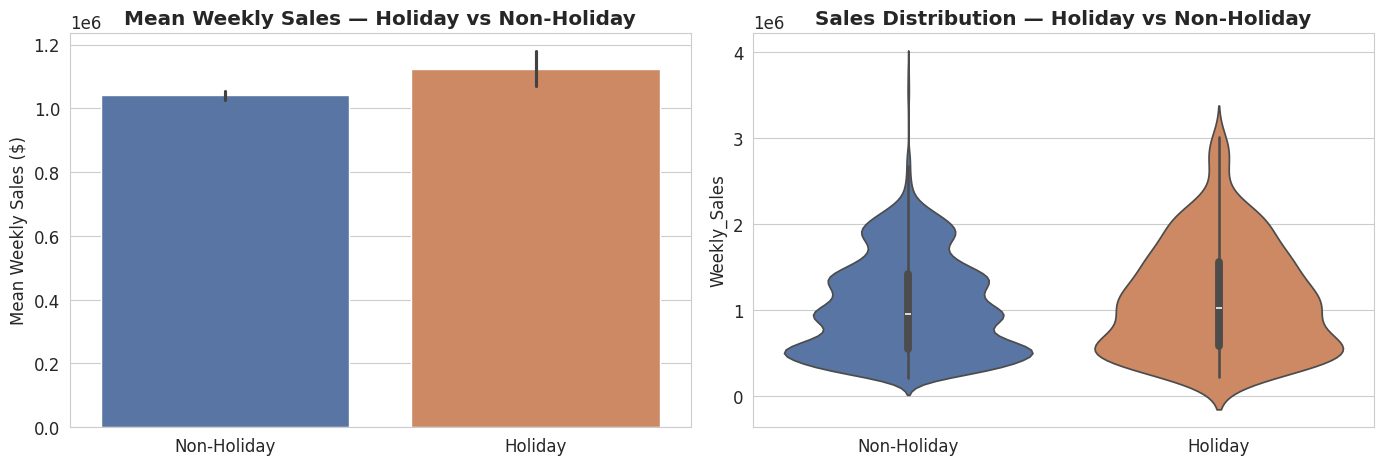


📊 Holiday Sales Lift: +7.8% over non-holiday weeks


In [14]:
# --- 3.6 Holiday vs Non-Holiday Sales Impact ---
holiday_impact = df.groupby('Holiday_Flag')['Weekly_Sales'].agg(['mean', 'median', 'sum']).reset_index()
holiday_impact['Holiday_Flag'] = holiday_impact['Holiday_Flag'].map({0: 'Non-Holiday', 1: 'Holiday'})
print(holiday_impact.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean comparison
sns.barplot(data=df, x='Holiday_Flag', y='Weekly_Sales', estimator=np.mean,
            palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Mean Weekly Sales — Holiday vs Non-Holiday', fontweight='bold')
axes[0].set_xticklabels(['Non-Holiday', 'Holiday'])
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Weekly Sales ($)')

# Violin plot
sns.violinplot(data=df, x='Holiday_Flag', y='Weekly_Sales',
               palette=['#4C72B0', '#DD8452'], inner='box', ax=axes[1])
axes[1].set_title('Sales Distribution — Holiday vs Non-Holiday', fontweight='bold')
axes[1].set_xticklabels(['Non-Holiday', 'Holiday'])
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('holiday_impact.png', bbox_inches='tight', dpi=150)
plt.show()

holiday_lift = ((df[df['Holiday_Flag']==1]['Weekly_Sales'].mean() /
                 df[df['Holiday_Flag']==0]['Weekly_Sales'].mean()) - 1) * 100


## Observation

- The average weekly sales during **holiday weeks** are higher than those during **non-holiday weeks**, indicating that holidays positively influence customer spending.

- The bar chart shows that mean weekly sales increase from approximately **$1.04 million** during non-holiday periods to around **$1.12 million** during holiday periods.

- The violin plot reveals that holiday sales exhibit a **wider distribution and greater variability**, suggesting that some holiday weeks generate exceptionally high sales.

- Although the overall distributions of holiday and non-holiday sales overlap, the holiday distribution is slightly shifted toward higher sales values.

- The presence of higher sales and increased variability during holiday periods highlights the significant impact of seasonal events on retail performance.

- These findings suggest that the **Holiday_Flag** feature is an important predictor and should be incorporated into the sales forecasting model to improve prediction accuracy.

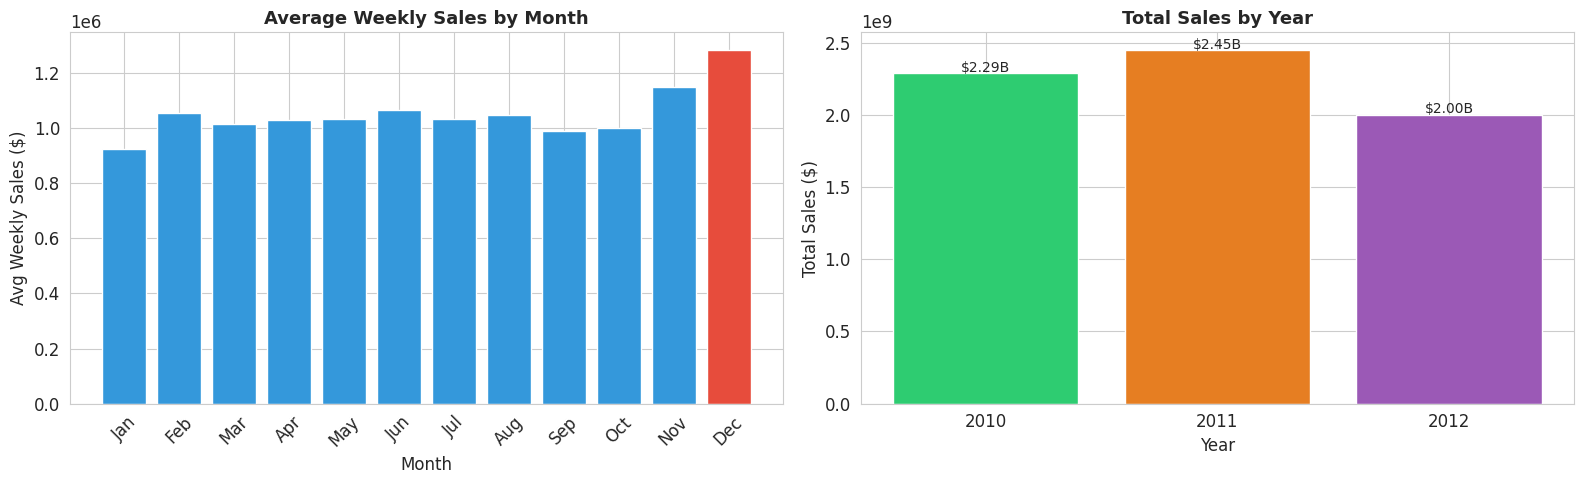

In [15]:
# --- 3.7 Monthly and Yearly Sales Seasonality ---
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Month_Name'] = df['Date'].dt.strftime('%b')

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales = df.groupby('Month_Name')['Weekly_Sales'].mean().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Monthly pattern
colors = ['#e74c3c' if s == monthly_sales.max() else '#3498db' for s in monthly_sales]
axes[0].bar(monthly_sales.index, monthly_sales.values, color=colors, edgecolor='white')
axes[0].set_title('Average Weekly Sales by Month', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].tick_params(axis='x', rotation=45)

# Yearly pattern
yearly = df.groupby('Year')['Weekly_Sales'].sum()
axes[1].bar(yearly.index.astype(str), yearly.values, color=['#2ecc71','#e67e22','#9b59b6'], edgecolor='white')
axes[1].set_title('Total Sales by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Sales ($)')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e7,
                 f"${bar.get_height()/1e9:.2f}B", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('seasonality.png', bbox_inches='tight', dpi=150)
plt.show()

## Observation

- The average weekly sales exhibit clear **seasonal patterns** throughout the year, with sales generally increasing during the latter months.

- **December** records the highest average weekly sales at approximately **$1.28 million**, likely driven by holiday shopping and year-end promotions.

- **January** shows the lowest average weekly sales, with an average of around **$0.92 million**, indicating a decline in consumer spending after the holiday season.

- Monthly sales remain relatively stable between **February and October**, fluctuating around the **$1.0–1.05 million** range.

- From the yearly analysis, **2011** generated the highest total sales (approximately **$2.45 billion**), followed by **2010** with **$2.29 billion**.

- Total sales for **2012** are comparatively lower (around **$2.00 billion**), which is likely due to the dataset containing only a partial year's data rather than a decline in business performance.

- These trends indicate that **month and seasonal effects** play an important role in sales behavior and should be incorporated into the forecasting model.

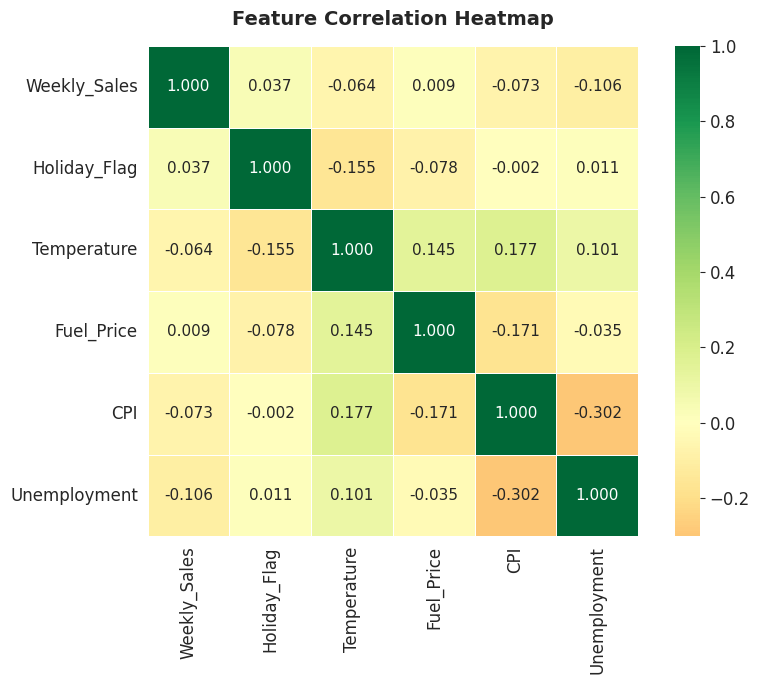


🔑 Key Correlations with Weekly_Sales:
Unemployment   -0.106176
CPI            -0.072634
Temperature    -0.063810
Holiday_Flag    0.036891
Fuel_Price      0.009464
Name: Weekly_Sales, dtype: float64


In [16]:
# --- 3.8 Correlation Heatmap ---
corr_cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, mask=False, square=True,
            annot_kws={'size': 11})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n Key Correlations with Weekly_Sales:")
print(corr['Weekly_Sales'].drop('Weekly_Sales').sort_values(key=abs, ascending=False))

## Observation

- The correlation heatmap indicates that there are **no strong linear relationships** between **Weekly Sales** and the other numerical features, as all correlation coefficients are relatively close to zero.

- **Unemployment** has the strongest relationship with Weekly Sales, showing a weak negative correlation (**-0.106**), suggesting that higher unemployment rates may slightly reduce sales.

- **CPI (-0.073)** and **Temperature (-0.064)** also exhibit weak negative correlations with Weekly Sales, indicating only a minimal impact on sales performance.

- **Holiday_Flag (0.037)** and **Fuel_Price (0.009)** have very weak positive correlations with Weekly Sales, implying that their direct linear influence is limited.

- Among the independent variables, **CPI and Unemployment** show the strongest correlation (**-0.302**), although it is still considered moderate.

- The absence of strong pairwise correlations suggests that sales are likely influenced by a combination of factors, including seasonality, store-specific characteristics, and non-linear relationships rather than any single variable alone.

- These findings indicate that advanced forecasting models capable of capturing complex patterns may perform better than models relying solely on linear relationships.

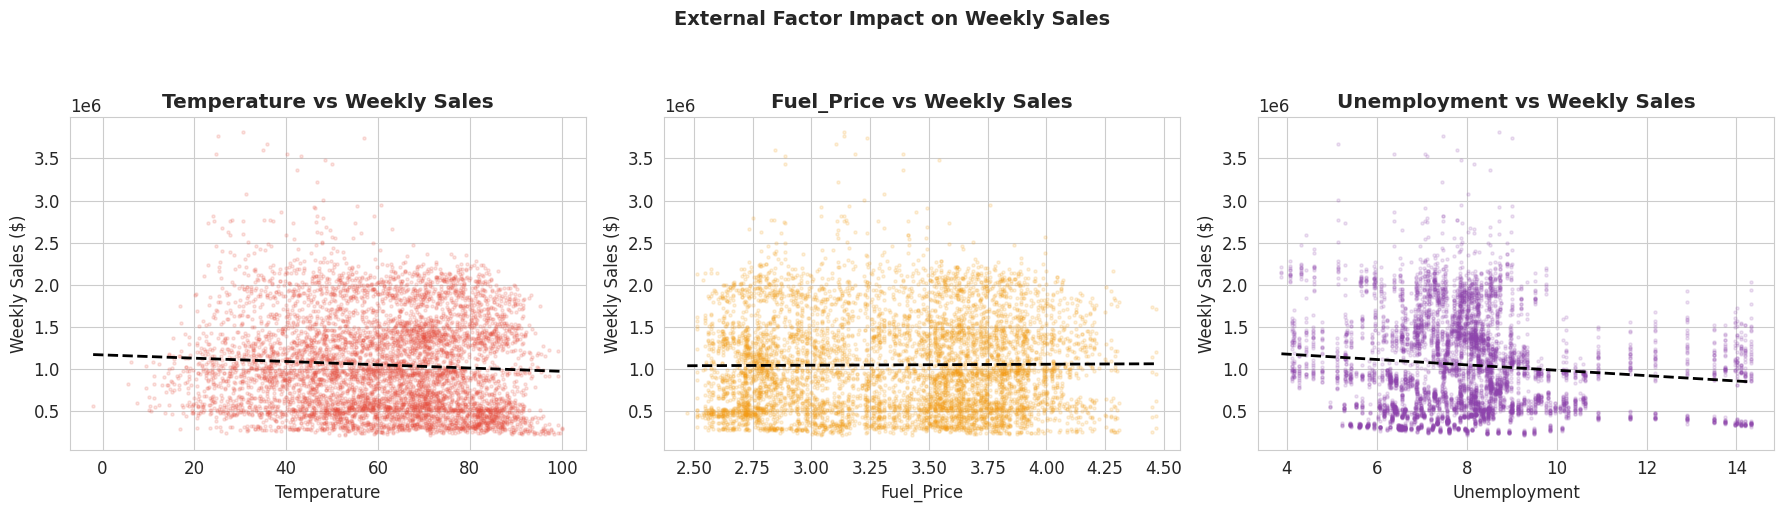

In [17]:
# --- 3.9 Temperature vs Sales Scatter ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, ['Temperature', 'Fuel_Price', 'Unemployment'],
                           ['#e74c3c', '#f39c12', '#8e44ad']):
    ax.scatter(df[col], df['Weekly_Sales'], alpha=0.15, color=color, s=5)
    # Trend line
    z = np.polyfit(df[col], df['Weekly_Sales'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Weekly Sales ($)')
    ax.set_title(f'{col} vs Weekly Sales', fontweight='bold')

plt.suptitle('External Factor Impact on Weekly Sales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('factor_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

## Observation

- The scatter plots indicate that **Temperature**, **Fuel Price**, and **Unemployment** have relatively weak relationships with Weekly Sales, as the data points are widely dispersed.

- **Temperature** exhibits a slight negative trend, suggesting that weekly sales tend to decrease marginally as temperature increases. However, the relationship is not strong.

- **Fuel Price** shows an almost flat trend line, indicating that variations in fuel costs have little direct impact on weekly sales.

- **Unemployment** demonstrates the most noticeable negative relationship among the three factors, implying that higher unemployment rates may be associated with lower consumer spending and reduced sales.

- Despite these trends, the large spread of observations suggests that external factors alone cannot fully explain variations in sales performance.

- These results indicate that sales are likely influenced by a combination of multiple factors, including holidays, seasonality, store-specific characteristics, and customer demand patterns, rather than any single external variable.

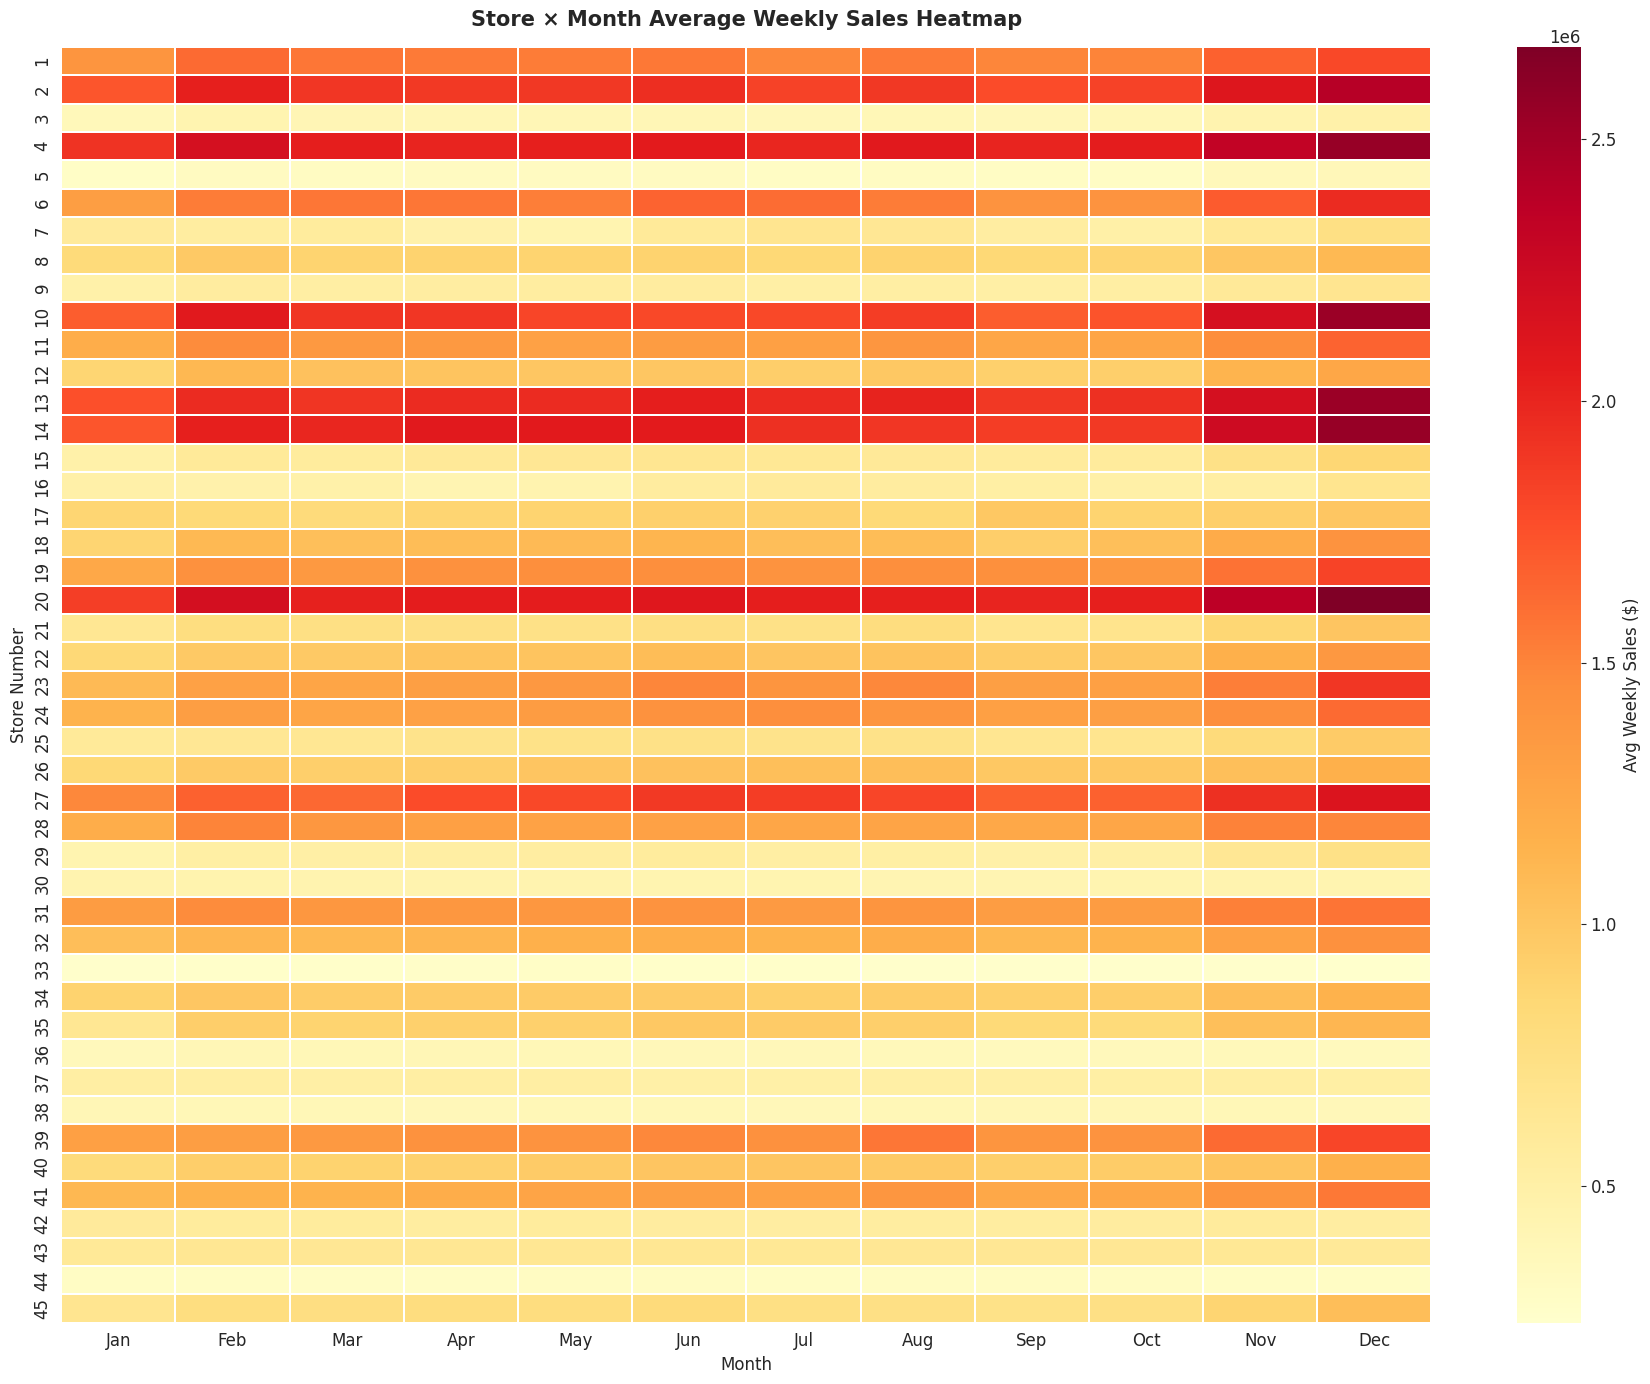

In [18]:
# --- 3.10 Store-Level Sales Heatmap (Store vs Month) ---
store_month = df.groupby(['Store', 'Month'])['Weekly_Sales'].mean().unstack()
store_month.columns = month_order[:store_month.shape[1]]

plt.figure(figsize=(18, 14))
sns.heatmap(store_month, cmap='YlOrRd', linewidths=0.2,
            annot=False, fmt='.0f', cbar_kws={'label': 'Avg Weekly Sales ($)'})
plt.title('Store × Month Average Weekly Sales Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Store Number', fontsize=12)
plt.tight_layout()
plt.savefig('store_month_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## Observation

- The heatmap reveals noticeable differences in average weekly sales across stores, indicating that store performance varies significantly throughout the year.

- Several stores, particularly **Stores 4, 10, 13, and 20**, consistently exhibit higher average weekly sales compared to others, making them the strongest revenue contributors.

- Most stores experience an increase in sales during **November and December**, reflecting the impact of holiday shopping and seasonal demand.

- Lower-performing stores maintain relatively stable but lower sales levels across all months, suggesting consistent yet limited customer demand.

- While monthly fluctuations are present, the overall sales pattern for each store remains fairly consistent, indicating that store-specific characteristics play an important role in determining sales performance.

- The clear seasonal peaks observed across many stores suggest that inventory planning and resource allocation should be adjusted during high-demand months, particularly at the end of the year.

- These patterns demonstrate that both **store-specific behavior** and **seasonality** are important factors and should be incorporated into the sales forecasting model.

---
##  Section 4: Key Business Insights

Summary of findings from EDA:

In [19]:
print("="*65)
print(" KEY BUSINESS INSIGHTS — WALMART SALES DATA")
print("="*65)

avg_sales = df['Weekly_Sales'].mean()
top_store = store_sales.idxmax()
bottom_store = store_sales.idxmin()
holiday_lift_val = ((df[df['Holiday_Flag']==1]['Weekly_Sales'].mean() /
                     df[df['Holiday_Flag']==0]['Weekly_Sales'].mean()) - 1) * 100
best_month = monthly_sales.idxmax()
worst_month = monthly_sales.idxmin()
unemp_corr = df['Unemployment'].corr(df['Weekly_Sales'])

insights = [
    f"1. Average weekly sales per store: ${avg_sales:,.0f}",
    f"2. Top-performing store: Store {top_store} (${store_sales.max()/1e6:.1f}M total)",
    f"3. Lowest-performing store: Store {bottom_store} (${store_sales.min()/1e6:.1f}M total)",
    f"4. Holiday weeks boost sales by +{holiday_lift_val:.1f}% on average",
    f"5. Peak sales month: {best_month} — stores should maximize inventory then",
    f"6. Slowest month: {worst_month} — opportunity for promotions/discounts",
    f"7. Unemployment negatively correlates with sales (r={unemp_corr:.3f})",
    f"8. Temperature has weak correlation — sales are largely weather-independent",
    f"9. Fuel price changes do not strongly directly impact weekly sales",
    f"10. Clear end-of-year surge visible (Nov-Dec) — holiday season effect",
    f"11. Top 5 stores account for a disproportionate share of total revenue",
    f"12. Low-performing stores may need targeted promotions or restructuring",
]

for insight in insights:
    print(insight)

 KEY BUSINESS INSIGHTS — WALMART SALES DATA
1. Average weekly sales per store: $1,046,965
2. Top-performing store: Store 20 ($301.4M total)
3. Lowest-performing store: Store 33 ($37.2M total)
4. Holiday weeks boost sales by +7.8% on average
5. Peak sales month: Dec — stores should maximize inventory then
6. Slowest month: Jan — opportunity for promotions/discounts
7. Unemployment negatively correlates with sales (r=-0.106)
8. Temperature has weak correlation — sales are largely weather-independent
9. Fuel price changes do not strongly directly impact weekly sales
10. Clear end-of-year surge visible (Nov-Dec) — holiday season effect
11. Top 5 stores account for a disproportionate share of total revenue
12. Low-performing stores may need targeted promotions or restructuring


---
##  Section 5: Feature Engineering

In [20]:
df_feat = df.copy()

# Date features
df_feat['Year']           = df_feat['Date'].dt.year
df_feat['Month']          = df_feat['Date'].dt.month
df_feat['Week_of_Year']   = df_feat['Date'].dt.isocalendar().week.astype(int)
df_feat['Quarter']        = df_feat['Date'].dt.quarter
df_feat['Is_Year_End']    = df_feat['Month'].isin([11, 12]).astype(int)
df_feat['Is_Summer']      = df_feat['Month'].isin([6, 7, 8]).astype(int)

# Lag features (per store)
df_feat = df_feat.sort_values(['Store', 'Date'])
df_feat['Sales_Lag1']     = df_feat.groupby('Store')['Weekly_Sales'].shift(1)
df_feat['Sales_Lag2']     = df_feat.groupby('Store')['Weekly_Sales'].shift(2)
df_feat['Sales_Lag4']     = df_feat.groupby('Store')['Weekly_Sales'].shift(4)

# Rolling stats (4-week moving average and std per store)
df_feat['Rolling_Mean_4'] = df_feat.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(4).mean())
df_feat['Rolling_Std_4']  = df_feat.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.shift(1).rolling(4).std())

# Store-level mean sales encoding
store_mean_map = df_feat.groupby('Store')['Weekly_Sales'].mean().to_dict()
df_feat['Store_Mean_Sales'] = df_feat['Store'].map(store_mean_map)

# Drop rows with NaN from lag creation
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

print(f"Dataset after feature engineering: {df_feat.shape}")
print("New features added:", ['Year', 'Month', 'Week_of_Year', 'Quarter',
                               'Is_Year_End', 'Is_Summer',
                               'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag4',
                               'Rolling_Mean_4', 'Rolling_Std_4', 'Store_Mean_Sales'])
df_feat.head()

Dataset after feature engineering: (6255, 22)
New features added: ['Year', 'Month', 'Week_of_Year', 'Quarter', 'Is_Year_End', 'Is_Summer', 'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag4', 'Rolling_Mean_4', 'Rolling_Std_4', 'Store_Mean_Sales']


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,...,Week_of_Year,Quarter,Is_Year_End,Is_Summer,Sales_Lag1,Sales_Lag2,Sales_Lag4,Rolling_Mean_4,Rolling_Std_4,Store_Mean_Sales
0,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,...,9,1,0,0,1409727.59,1611968.17,1643690.90,1.576836e+06,112353.415114,1.555264e+06
1,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,...,10,1,0,0,1554806.68,1409727.59,1641957.44,1.554615e+06,103135.002548,1.555264e+06
2,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,...,11,1,0,0,1439541.59,1554806.68,1611968.17,1.504011e+06,95360.050839,1.555264e+06
3,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,...,12,1,0,0,1472515.79,1439541.59,1409727.59,1.469148e+06,62599.457150,1.555264e+06
4,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,...,13,2,0,0,1404429.92,1472515.79,1554806.68,1.467823e+06,64308.381016,1.555264e+06


---
##  Section 6: ML Models for Sales Prediction

We train and compare **4 regression models** on historical data.

In [21]:
# --- 6.1 Feature Selection & Train-Test Split ---
FEATURES = ['Store', 'Year', 'Month', 'Week_of_Year', 'Quarter',
            'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
            'Is_Year_End', 'Is_Summer',
            'Sales_Lag1', 'Sales_Lag2', 'Sales_Lag4',
            'Rolling_Mean_4', 'Rolling_Std_4', 'Store_Mean_Sales']

TARGET = 'Weekly_Sales'

X = df_feat[FEATURES]
y = df_feat[TARGET]

# Chronological split — last 20% as test
split_idx = int(len(df_feat) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {X_train.shape[0]} rows | Test size: {X_test.shape[0]} rows")

Train size: 5004 rows | Test size: 1251 rows


In [22]:
# --- 6.2 Model Training & Evaluation ---
from sklearn.metrics import mean_absolute_percentage_error

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae   = mean_absolute_error(y_te, preds)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    r2    = r2_score(y_te, preds)
    mape  = mean_absolute_percentage_error(y_te, preds) * 100
    print(f"{name:<30} MAE=${mae:>12,.0f}  RMSE=${rmse:>12,.0f}  R²={r2:.4f}  MAPE={mape:.2f}%")
    return model, preds, {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print(f"{'Model':<30} {'MAE':>16} {'RMSE':>16} {'R²':>8} {'MAPE':>10}")
print("-" * 85)

results = []
models  = {}

# Linear Regression
lr = LinearRegression()
m, p, r = evaluate_model('Linear Regression', lr, X_train, y_train, X_test, y_test)
models['Linear Regression'] = (m, p); results.append(r)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
m, p, r = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)
models['Random Forest'] = (m, p); results.append(r)

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
m, p, r = evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test)
models['Gradient Boosting'] = (m, p); results.append(r)

# XGBoost
xgbr = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                         random_state=42, verbosity=0)
m, p, r = evaluate_model('XGBoost', xgbr, X_train, y_train, X_test, y_test)
models['XGBoost'] = (m, p); results.append(r)

Model                                       MAE             RMSE       R²       MAPE
-------------------------------------------------------------------------------------
Linear Regression              MAE=$      60,847  RMSE=$      97,985  R²=0.9372  MAPE=8.90%
Random Forest                  MAE=$      44,359  RMSE=$      65,504  R²=0.9719  MAPE=6.18%
Gradient Boosting              MAE=$      42,861  RMSE=$      61,641  R²=0.9751  MAPE=5.82%
XGBoost                        MAE=$      42,887  RMSE=$      69,499  R²=0.9684  MAPE=6.02%


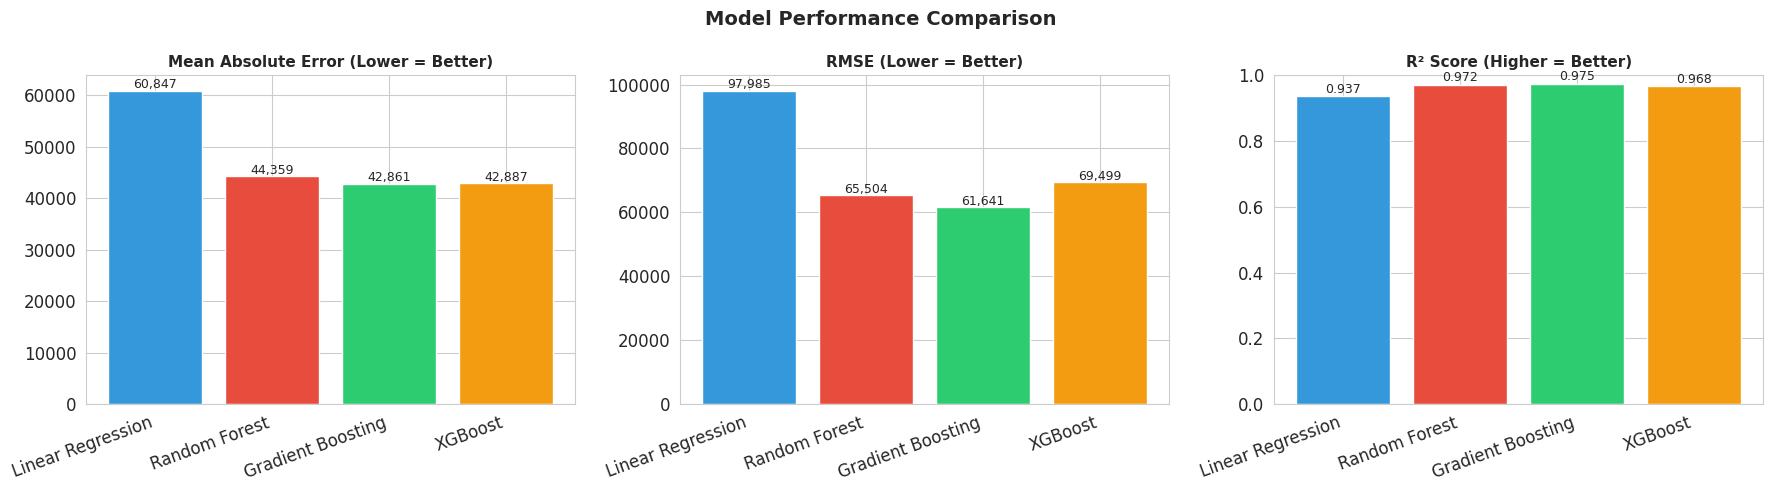


 Best Model: Gradient Boosting (R² = 0.9751)


In [23]:
# --- 6.3 Model Comparison Chart ---
results_df = pd.DataFrame(results).set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for ax, metric, title in zip(axes, ['MAE', 'RMSE', 'R2'],
                              ['Mean Absolute Error (Lower = Better)',
                               'RMSE (Lower = Better)', 'R² Score (Higher = Better)']):
    bars = ax.bar(results_df.index, results_df[metric], color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticklabels(results_df.index, rotation=20, ha='right')
    if metric == 'R2':
        ax.set_ylim(0, 1)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{bar.get_height():.3f}" if metric == 'R2' else f"{bar.get_height():,.0f}",
                ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

best_model_name = results_df['R2'].idxmax()
print(f"\n Best Model: {best_model_name} (R² = {results_df.loc[best_model_name, 'R2']:.4f})")

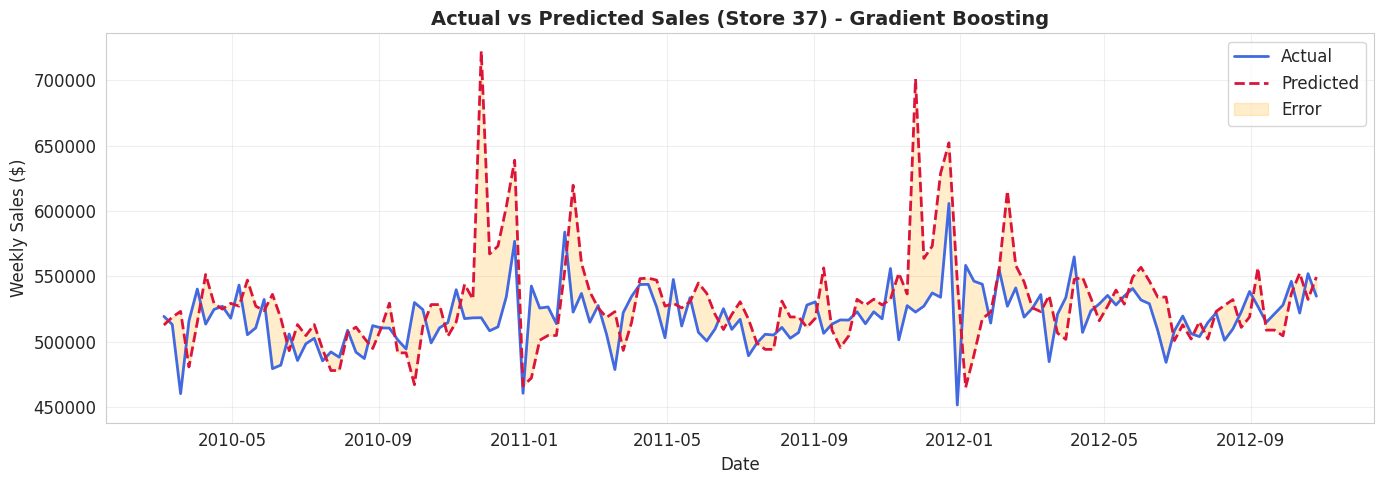

In [26]:
# --- 6.4 Actual vs Predicted Plot (Best Model) ---

best_model, best_preds = models[best_model_name]

# Test portion of the data
test_data = df_feat.iloc[split_idx:].copy()

# Automatically choose a store available in the test set
store_id = test_data['Store'].iloc[0]

# Filter data for that store
test_df_store = test_data[test_data['Store'] == store_id]

# Generate predictions
store_preds = best_model.predict(test_df_store[FEATURES])

# Plot
plt.figure(figsize=(14, 5))

plt.plot(
    test_df_store['Date'],
    test_df_store['Weekly_Sales'],
    label='Actual',
    color='royalblue',
    linewidth=2
)

plt.plot(
    test_df_store['Date'],
    store_preds,
    label='Predicted',
    color='crimson',
    linewidth=2,
    linestyle='--'
)

# Error shading
plt.fill_between(
    test_df_store['Date'],
    test_df_store['Weekly_Sales'],
    store_preds,
    alpha=0.2,
    color='orange',
    label='Error'
)

plt.title(
    f'Actual vs Predicted Sales (Store {store_id}) - {best_model_name}',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    'actual_vs_predicted.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Observation

- The **Gradient Boosting model** is able to capture the overall trend and seasonal fluctuations in weekly sales, with the predicted values closely following the actual sales pattern.

- For most time periods, the predicted sales remain near the actual observations, indicating that the model has learned the underlying relationships in the data effectively.

- The model tends to **slightly overestimate sales during periods of unusually high demand**, particularly around major sales peaks, where the predicted values exceed the actual sales.

- Despite these deviations, the prediction errors are relatively small for the majority of observations, as reflected by the narrow gap between the actual and predicted curves.

- The model successfully captures both regular sales fluctuations and seasonal variations, making it suitable for short-term sales forecasting.

- Overall, the close alignment between the actual and predicted values, along with the high evaluation metrics obtained earlier (**R² = 0.9751** and **MAPE = 5.82%**), demonstrates that the **Gradient Boosting model provides accurate and reliable sales predictions**.

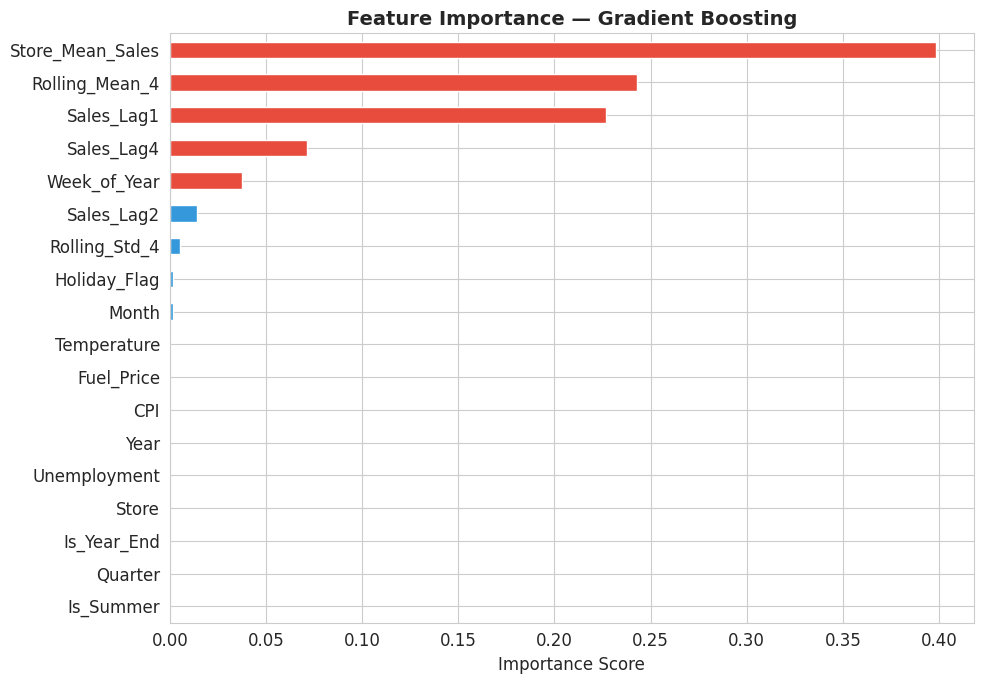

Top 5 important features:
Store_Mean_Sales    0.398276
Rolling_Mean_4      0.242775
Sales_Lag1          0.226828
Sales_Lag4          0.071127
Week_of_Year        0.037269
dtype: float64


In [27]:
# --- 6.5 Feature Importance (XGBoost / Random Forest) ---
if best_model_name in ['XGBoost', 'Random Forest', 'Gradient Boosting']:
    importances = pd.Series(best_model.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(10, 7))
    colors_feat = ['#e74c3c' if i >= len(importances) - 5 else '#3498db'
                   for i in range(len(importances))]
    importances.plot(kind='barh', color=colors_feat)
    plt.title(f'Feature Importance — {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
    plt.show()

    print("Top 5 important features:")
    print(importances.tail(5).sort_values(ascending=False))

## Observation

- The feature importance analysis indicates that **historical sales patterns** are the most influential factors in predicting future weekly sales.

- **Store_Mean_Sales** is the most important feature, contributing approximately **40%** of the model's predictive power. This suggests that the average historical performance of a store is a strong indicator of future sales.

- **Rolling_Mean_4** and **Sales_Lag1** are the next most significant features, highlighting the importance of recent sales trends and short-term temporal dependencies in forecasting.

- **Sales_Lag4** and **Week_of_Year** also contribute meaningfully, indicating that both monthly sales patterns and seasonal effects play a role in determining weekly sales.

- External factors such as **Temperature**, **Fuel Price**, **CPI**, and **Unemployment** have minimal importance in the Gradient Boosting model, suggesting that their direct influence on sales is relatively weak.

- Similarly, calendar-based features such as **Month**, **Quarter**, **Is_Year_End**, and **Is_Summer** contribute little compared to historical sales-based features.

- Overall, the model relies primarily on **store-specific historical performance and recent sales behavior**, demonstrating that past sales trends are the strongest predictors of future demand.

---
## Section 7: 12-Week Sales Forecast Per Store (Prophet)

We use **Facebook Prophet** — a robust time-series forecasting model — to predict the next 12 weeks for **each store** individually.

In [29]:
# --- 7.1 Prophet Forecast for All 45 Stores ---
from prophet import Prophet

FORECAST_WEEKS = 12
all_forecasts = []

print(f"Forecasting next {FORECAST_WEEKS} weeks for each store...")

for store_id in sorted(df['Store'].unique()):
    store_df = df[df['Store'] == store_id][['Date', 'Weekly_Sales']].rename(
        columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    store_df = store_df.sort_values('ds').reset_index(drop=True)

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05
    )

    # Add holiday flag as a regressor via special events
    holiday_dates_store = df[(df['Store'] == store_id) & (df['Holiday_Flag'] == 1)][['Date']].copy()
    holiday_dates_store.columns = ['ds']
    holiday_dates_store['holiday'] = 'holiday_week'
    holiday_dates_store['lower_window'] = 0
    holiday_dates_store['upper_window'] = 0

    model = Prophet(
        holidays=holiday_dates_store,
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        interval_width=0.95
    )

    model.fit(store_df)

    future = model.make_future_dataframe(periods=FORECAST_WEEKS, freq='W')
    forecast = model.predict(future)

    # Keep only future 12 weeks
    last_date = store_df['ds'].max()
    future_forecast = forecast[forecast['ds'] > last_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
    future_forecast['Store'] = store_id
    all_forecasts.append(future_forecast)

forecast_df = pd.concat(all_forecasts, ignore_index=True)
forecast_df.rename(columns={'ds': 'Date', 'yhat': 'Predicted_Sales',
                             'yhat_lower': 'Lower_CI', 'yhat_upper': 'Upper_CI'}, inplace=True)
forecast_df['Predicted_Sales'] = forecast_df['Predicted_Sales'].clip(lower=0)
forecast_df['Lower_CI']        = forecast_df['Lower_CI'].clip(lower=0)

print(f"\n Forecast complete! {len(forecast_df)} rows ({FORECAST_WEEKS} weeks × 45 stores)")
forecast_df.head(15)

Forecasting next 12 weeks for each store...

 Forecast complete! 540 rows (12 weeks × 45 stores)


,Date,Predicted_Sales,Lower_CI,Upper_CI,Store
0,2012-10-28,1.532967e+06,1.328322e+06,1.744551e+06,1
1,2012-11-04,1.603230e+06,1.386188e+06,1.811828e+06,1
2,2012-11-11,1.689336e+06,1.494296e+06,1.887269e+06,1
3,2012-11-18,1.738205e+06,1.531819e+06,1.935922e+06,1
4,2012-11-25,1.758021e+06,1.560188e+06,1.961429e+06,1
5,2012-12-02,1.811349e+06,1.612149e+06,1.995698e+06,1
6,2012-12-09,1.929131e+06,1.717476e+06,2.135560e+06,1
7,2012-12-16,2.044361e+06,1.850904e+06,2.260837e+06,1
8,2012-12-23,2.035403e+06,1.826478e+06,2.249810e+06,1
9,2012-12-30,1.848658e+06,1.640173e+06,2.058720e+06,1


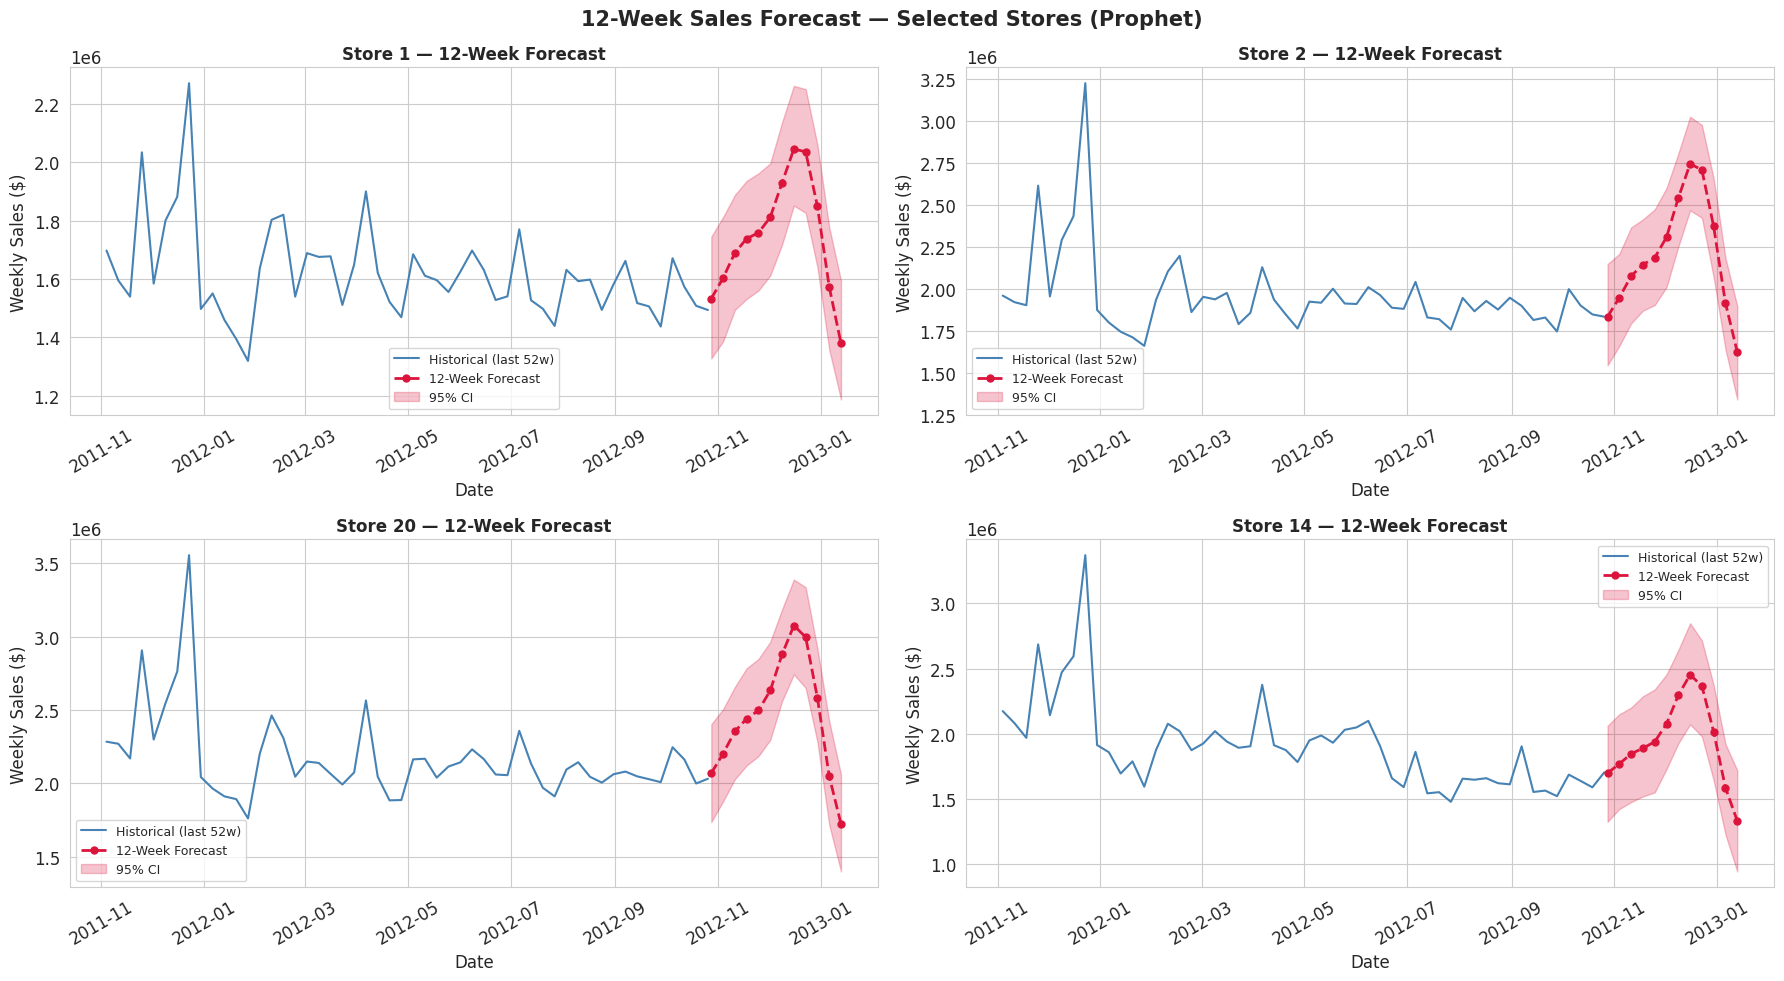

In [30]:
# --- 7.2 Visualize Forecast for Selected Stores ---
stores_to_plot = [1, 2, 20, 14]   # Change to any store numbers you want

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, store_id in enumerate(stores_to_plot):
    hist = df[df['Store'] == store_id][['Date', 'Weekly_Sales']].tail(52)
    fcast = forecast_df[forecast_df['Store'] == store_id]

    ax = axes[idx]
    ax.plot(hist['Date'], hist['Weekly_Sales'],
            label='Historical (last 52w)', color='steelblue', linewidth=1.5)
    ax.plot(fcast['Date'], fcast['Predicted_Sales'],
            label='12-Week Forecast', color='crimson', linewidth=2, linestyle='--', marker='o', markersize=5)
    ax.fill_between(fcast['Date'], fcast['Lower_CI'], fcast['Upper_CI'],
                    alpha=0.25, color='crimson', label='95% CI')
    ax.set_title(f'Store {store_id} — 12-Week Forecast', fontweight='bold', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('Weekly Sales ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('12-Week Sales Forecast — Selected Stores (Prophet)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('12week_forecast_stores.png', bbox_inches='tight', dpi=150)
plt.show()

## Observation

- The 12-week sales forecasts for the selected stores (**Stores 1, 2, 14, and 20**) indicate a clear seasonal increase in sales during the initial forecast period, followed by a gradual decline toward the end of the horizon.

- All four stores exhibit a similar forecasting pattern, suggesting that the model has successfully captured the underlying seasonal trends present in the historical data.

- The highest forecasted sales are observed around the holiday season, where weekly sales are expected to reach approximately **$2.0–3.1 million**, depending on the store.

- **Store 20** is projected to maintain the highest sales levels among the selected stores, while **Store 1** records comparatively lower forecasted values, consistent with their historical performance.

- The shaded **95% confidence intervals** widen as the forecast horizon increases, indicating greater uncertainty in long-term predictions compared to short-term forecasts.

- The forecast curves closely follow the recent historical trends, demonstrating that the forecasting model effectively captures both seasonality and store-specific demand patterns.

- These forecasts can support inventory planning, workforce allocation, and promotional strategies by helping management anticipate future demand across different stores.

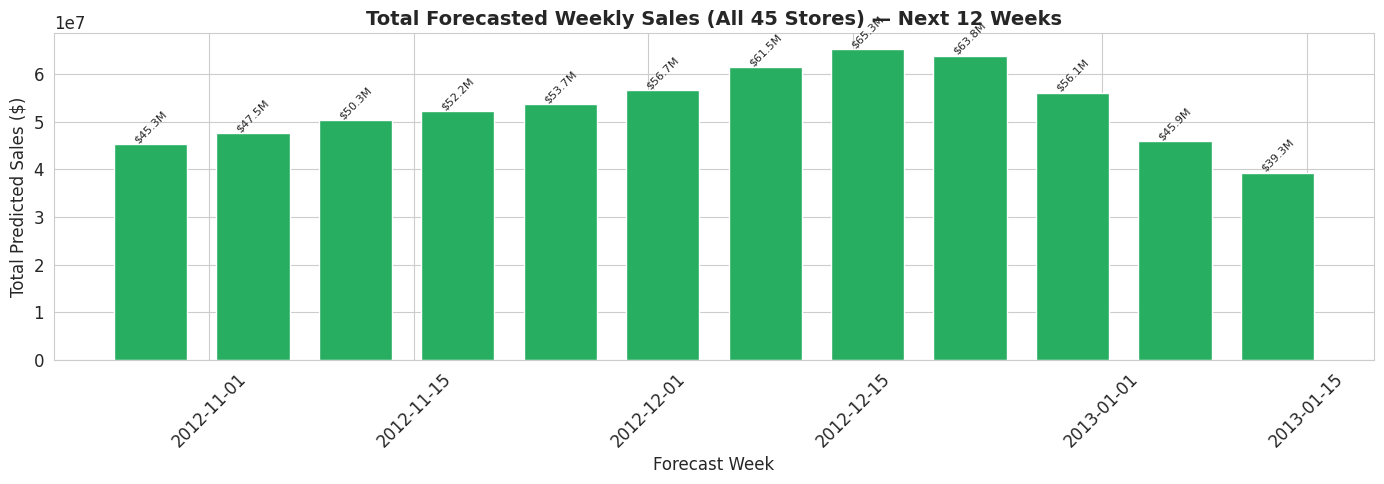

Total forecasted revenue across all stores: $0.638B


In [32]:
# --- 7.3 Total Forecasted Sales Across All Stores ---
total_forecast = forecast_df.groupby('Date')['Predicted_Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.bar(total_forecast['Date'], total_forecast['Predicted_Sales'],
        color='#27ae60', edgecolor='white', width=5)
for i, (_, row) in enumerate(total_forecast.iterrows()):
    plt.text(row['Date'], row['Predicted_Sales'] + 2e5,
             f"${row['Predicted_Sales']/1e6:.1f}M", ha='center', fontsize=8, rotation=45)
plt.title('Total Forecasted Weekly Sales (All 45 Stores) — Next 12 Weeks',
          fontsize=14, fontweight='bold')
plt.xlabel('Forecast Week')
plt.ylabel('Total Predicted Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('total_12week_forecast.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Total forecasted revenue across all stores: ${total_forecast['Predicted_Sales'].sum()/1e9:.3f}B")

## Observation

- The 12-week sales forecast for all **45 stores** indicates a gradual increase in total weekly sales during the initial forecast period, followed by a decline after the holiday season.

- Forecasted weekly sales are expected to rise from approximately **$45.3 million** in the first week to a peak of around **$65.3 million** during mid-December.

- The highest projected sales coincide with the year-end holiday period, reflecting the strong seasonal demand observed in the historical data.

- After reaching the peak, total sales are forecasted to decline steadily, falling to approximately **$39.3 million** by the end of the forecast horizon as post-holiday demand subsides.

- The forecast pattern closely aligns with the historical seasonality of Walmart sales, suggesting that the model has effectively captured recurring annual trends.

- These projections can assist management in optimizing inventory levels, staffing requirements, and promotional activities, particularly during the high-demand holiday weeks.

In [33]:
# --- 7.4 Export Forecast to CSV ---
forecast_export = forecast_df[['Store', 'Date', 'Predicted_Sales', 'Lower_CI', 'Upper_CI']]
forecast_export.to_csv('Walmart_12Week_Forecast.csv', index=False)
print(" Forecast saved to Walmart_12Week_Forecast.csv")
forecast_export.head(20)

 Forecast saved to Walmart_12Week_Forecast.csv


,Store,Date,Predicted_Sales,Lower_CI,Upper_CI
0,1,2012-10-28,1.532967e+06,1.328322e+06,1.744551e+06
1,1,2012-11-04,1.603230e+06,1.386188e+06,1.811828e+06
2,1,2012-11-11,1.689336e+06,1.494296e+06,1.887269e+06
3,1,2012-11-18,1.738205e+06,1.531819e+06,1.935922e+06
4,1,2012-11-25,1.758021e+06,1.560188e+06,1.961429e+06
5,1,2012-12-02,1.811349e+06,1.612149e+06,1.995698e+06
6,1,2012-12-09,1.929131e+06,1.717476e+06,2.135560e+06
7,1,2012-12-16,2.044361e+06,1.850904e+06,2.260837e+06
8,1,2012-12-23,2.035403e+06,1.826478e+06,2.249810e+06
9,1,2012-12-30,1.848658e+06,1.640173e+06,2.058720e+06


In [35]:
# --- 7.5 Forecast Pivot Table (Store × Week) ---
pivot = forecast_df.pivot_table(index='Store', columns='Date',
                                values='Predicted_Sales', aggfunc='mean')
pivot.columns = [f"Week {i+1}\n{c.strftime('%d %b')}" for i, c in enumerate(pivot.columns)]
pivot = pivot.round(0)
print("\n 12-Week Forecast Pivot Table (Store × Week) — Predicted Sales ($)")
print("(Showing first 10 stores)")
pivot.head(10).style.background_gradient(cmap='YlGn', axis=1)


 12-Week Forecast Pivot Table (Store × Week) — Predicted Sales ($)
(Showing first 10 stores)


,Week 1 28 Oct,Week 2 04 Nov,Week 3 11 Nov,Week 4 18 Nov,Week 5 25 Nov,Week 6 02 Dec,Week 7 09 Dec,Week 8 16 Dec,Week 9 23 Dec,Week 10 30 Dec,Week 11 06 Jan,Week 12 13 Jan
Store,,,,,,,,,,,,
1,1532967.000000,1603230.000000,1689336.000000,1738205.000000,1758021.000000,1811349.000000,1929131.000000,2044361.000000,2035403.000000,1848658.000000,1572982.000000,1379212.000000
2,1834048.000000,1947972.000000,2076247.000000,2144157.000000,2185117.000000,2307469.000000,2540891.000000,2743963.000000,2707967.000000,2371219.000000,1915193.000000,1624617.000000
3,419101.000000,440263.000000,467501.000000,491678.000000,513389.000000,538813.000000,565294.000000,575556.000000,551244.000000,493718.000000,429395.000000,391788.000000
4,2211124.000000,2342602.000000,2476443.000000,2538575.000000,2566536.000000,2677716.000000,2910916.000000,3123359.000000,3091072.000000,2736229.000000,2242644.000000,1919733.000000
5,319119.000000,336037.000000,365265.000000,392579.000000,409542.000000,419807.000000,429111.000000,432506.000000,416720.000000,377039.000000,328886.000000,298441.000000
6,1427214.000000,1517070.000000,1646819.000000,1750875.000000,1824679.000000,1930989.000000,2099776.000000,2240894.000000,2197340.000000,1909221.000000,1512561.000000,1246108.000000
7,523982.000000,557608.000000,615126.000000,664346.000000,686556.000000,703803.000000,755533.000000,843865.000000,912114.000000,891577.000000,773776.000000,629244.000000
8,894272.000000,936273.000000,996468.000000,1039923.000000,1067461.000000,1113995.000000,1194587.000000,1263315.000000,1243339.000000,1106182.000000,916167.000000,786722.000000
9,557882.000000,593424.000000,635587.000000,661707.000000,676212.000000,703985.000000,752948.000000,790904.000000,769735.000000,676347.000000,555685.000000,477879.000000


---
##  Section 8: Summary & Recommendations